In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import pandas as pd

# Load both CSVs
trend_df = pd.read_csv("../datasets/eth_trend_strength.csv")
vol_df = pd.read_csv("../datasets/eth_vol_filter_post_trade.csv")

# Keep only the columns you need from vol_df
vol_df = vol_df[[
    "date",
    "position","price"]]

# Rename vol filter columns to avoid clashes
vol_df = vol_df.rename(columns={
    "position": "vol_position",
})

trend_df = trend_df[[
    "date",
    "position",]]

trend_df = trend_df.rename(columns={
    "position": "trend_position",
})

# Merge on date
combined = trend_df.merge(vol_df, on="date", how="left")

# Create final combined position:
# Only take a position if BOTH strategies agree
combined["position"] = 0

combined.loc[
    (combined["trend_position"] == 1) & (combined["vol_position"] == 1),
    "position"
] = 1

combined.loc[
    (combined["trend_position"] == -1) & (combined["vol_position"] == -1),
    "position"
] = -1


# Save output
combined.to_csv("../datasets/eth_combined_strategy.csv", index=False)

combined.head()

,date,trend_position,vol_position,price,position
0,2018-01-01,0,0,772.640991,0
1,2018-01-02,0,0,884.443970,0
2,2018-01-03,0,1,962.719971,0
3,2018-01-04,0,1,980.921997,0
4,2018-01-05,0,1,997.719971,0


In [3]:
combined['position'].value_counts()

position
 0    1873
 1    1039
-1       9
Name: count, dtype: int64

In [4]:
import pandas as pd

# Load both CSVs
btc_trend_df = pd.read_csv("../datasets/btc_trend_strength.csv")
btc_vol_df = pd.read_csv("../datasets/btc_vol_filter_post_trade.csv")

# Keep only the columns you need from vol_df
btc_vol_df = btc_vol_df[[
    "date",
    "position","price"]]

# Rename vol filter columns to avoid clashes
btc_vol_df = btc_vol_df.rename(columns={
    "position": "vol_position",
})

btc_trend_df = btc_trend_df[[
    "date",
    "position",]]

btc_trend_df = btc_trend_df.rename(columns={
    "position": "trend_position",
})

# Merge on date
btc_combined = btc_trend_df.merge(btc_vol_df, on="date", how="left")

# Create final combined position:
# Only take a position if BOTH strategies agree
btc_combined["position"] = 0

btc_combined.loc[
    (btc_combined["trend_position"] == 1) & (btc_combined["vol_position"] == 1),
    "position"
] = 1

btc_combined.loc[
    (btc_combined["trend_position"] == -1) & (btc_combined["vol_position"] == -1),
    "position"
] = -1


# Save output
btc_combined.to_csv("../datasets/btc_combined_strategy.csv", index=False)

btc_combined.head()

,date,trend_position,vol_position,price,position
0,2018-01-01,0,0,13657.200195,0
1,2018-01-02,0,0,14982.099609,0
2,2018-01-03,0,1,15201.000000,0
3,2018-01-04,0,1,15599.200195,0
4,2018-01-05,0,1,17429.500000,0


In [5]:
btc_combined['position'].value_counts()

position
 0    1919
 1     983
-1      19
Name: count, dtype: int64

### Evaluation

#### ETH 

In [6]:
from evaluation_function import evaluate_strategy_full, plot_strategy_vs_buy_hold


--- Final Strategy Performance ---
cumulative_pnl: 57.2970
average_daily_pnl: 0.0017
max_drawdown: -0.6333
annualised_return: 0.6620
sharpe_ratio_rf_3pct: 1.1912
daily_std_dev: 0.0267
annualised_volatility: 0.5100
exposure_rate: 0.3588
total_turnover: 232.0000
number_of_trades_total: 116.0000
number_of_complete_trades: 116.0000
win_rate: 0.6207
average_trade_return: 0.0478
median_trade_return: 0.0155
average_win_return: 0.1248
average_loss_return: -0.0782
profit_factor: 2.6110
payoff_ratio: 1.5956
expectancy_per_trade: 0.0478
best_trade: 0.8243
worst_trade: -0.3324
average_holding_periods: 9.0345
median_holding_periods: 4.0000
long_trades: 114.0000
short_trades: 2.0000


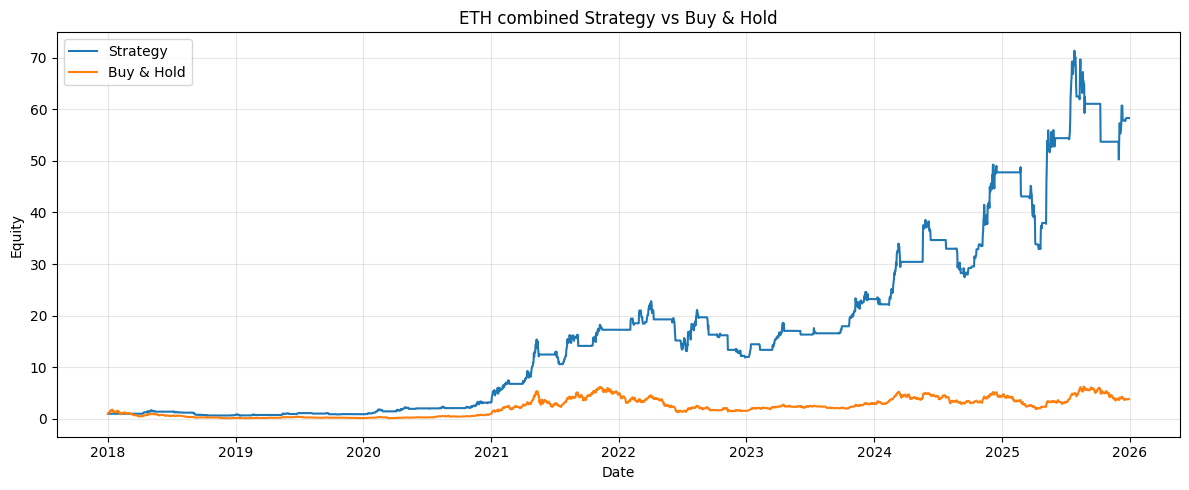

In [7]:
# Step 4: Final Evaluation
daily_eval, trade_log, summary = evaluate_strategy_full(combined, fee=0.00, rf_annual=0.03)
print("\n--- Final Strategy Performance ---")

for k, v in summary.items():
    print(f"{k}: {v:.4f}")

plot_strategy_vs_buy_hold(daily_eval, title="ETH combined Strategy vs Buy & Hold")
plt.show()

#### btc


--- Final Strategy Performance ---
cumulative_pnl: 21.5518
average_daily_pnl: 0.0013
max_drawdown: -0.4726
annualised_return: 0.4760
sharpe_ratio_rf_3pct: 1.1512
daily_std_dev: 0.0195
annualised_volatility: 0.3721
exposure_rate: 0.3430
total_turnover: 262.0000
number_of_trades_total: 131.0000
number_of_complete_trades: 131.0000
win_rate: 0.5725
average_trade_return: 0.0300
median_trade_return: 0.0072
average_win_return: 0.0870
average_loss_return: -0.0463
profit_factor: 2.5187
payoff_ratio: 1.8806
expectancy_per_trade: 0.0300
best_trade: 0.5864
worst_trade: -0.2071
average_holding_periods: 7.6489
median_holding_periods: 5.0000
long_trades: 126.0000
short_trades: 5.0000


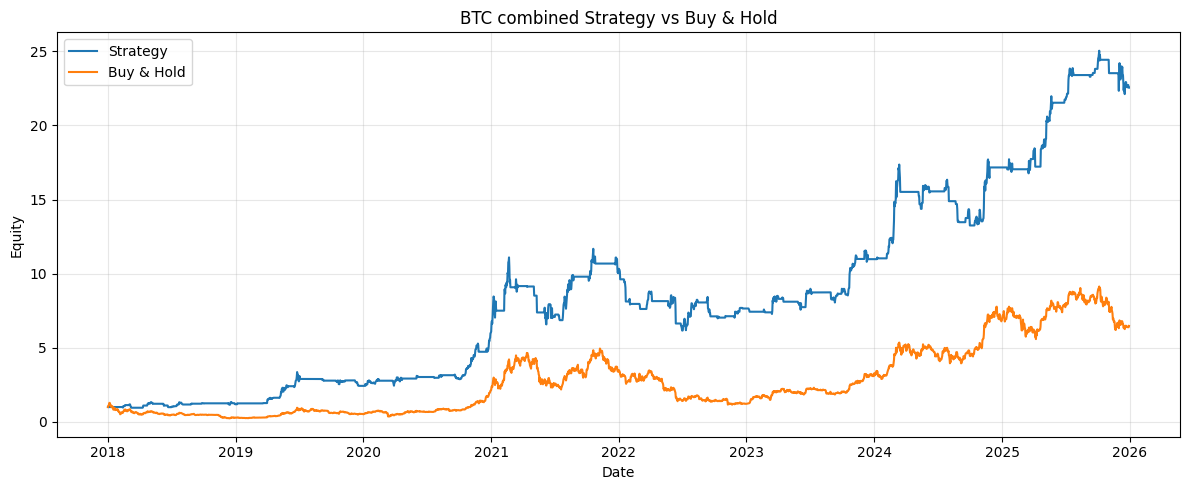

In [8]:
# Step 4: Final Evaluation
daily_eval, trade_log, summary = evaluate_strategy_full(btc_combined, fee=0.00, rf_annual=0.03)
print("\n--- Final Strategy Performance ---")

for k, v in summary.items():
    print(f"{k}: {v:.4f}")

plot_strategy_vs_buy_hold(daily_eval, title="BTC combined Strategy vs Buy & Hold")
plt.show()